In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [42]:
df = pd.read_csv(
    r"C:\Users\TIRTH\OneDrive\Desktop\python\cumulative_2026.03.14_07.05.16.csv",
    skiprows=53,
    low_memory=False
)

df.drop(columns=[    #dropping unnecessary columns
"kepid",
"kepoi_name",
"kepler_name",
"ra",
"dec",
"koi_tce_delivname",
"koi_score",
"koi_fpflag_nt",
"koi_fpflag_ss",
"koi_fpflag_co",
"koi_fpflag_ec",
"koi_teq_err1",
"koi_teq_err2"
], inplace=True)

df.head()

df.fillna(df.mean(numeric_only=True), inplace=True) #filling missing value with mean of column
df.isnull().sum()#checking for null values after filling
df.shape  

(9564, 36)

(array([ 60., 610., 546., 437., 439., 397., 437., 440., 469., 452., 417.,
        418., 432., 374., 364., 323., 258., 251., 235., 197., 161., 153.,
        164., 150., 122., 122., 162., 133., 154., 343., 159., 132.,  41.,
          2.,   2.,   2.,   3.,   1.,   1.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   1.]),
 array([ 0.2165962 ,  0.40924068,  0.60188516,  0.79452964,  0.98717412,
         1.17981859,  1.37246307,  1.56510755,  1.75775203,  1.95039651,
         2.14304099,  2.33568547,  2.52832995,  2.72097443,  2.91361891,
         3.10626339,  3.29890787,  3.49155234,  3.68419682,  3.8768413 ,
         4.06948578,  4.26213026,  4.45477474,  4.64741922,  4.8400637 ,
         5.03270818,  5.22535266,  5.41799714,  5.61064162,  5.80328609,
         5.99593057,  6.18857505,  6.38121953,  6.57386401,  6.76650849,
         6.95915297,  7.15179745,  7.34444193,  7.53708641,  7.72973089,
      

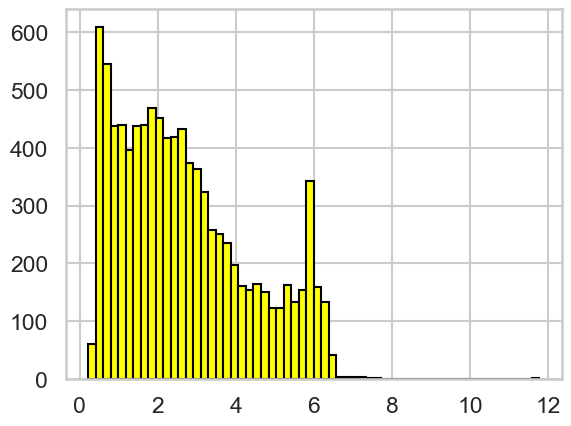

In [43]:
df["koi_disposition"].value_counts()
plt.hist(np.log1p(df["koi_period"]),bins=60,color="yellow",edgecolor="black")


In [44]:
df["label"]=df["koi_disposition"].apply(lambda x: 1 if (x=="CONFIRMED" or x=="CANDIDATE") else 0)
df.drop(columns=["koi_disposition","koi_pdisposition"],inplace=True)

In [45]:
X=df.drop(columns=["label"])
y=df["label"]

In [46]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=18
)

# parameter search
param_grid = {
    "n_estimators": [100,300,500],
    "max_depth": [None,10,20],
    "min_samples_split": [2,5,10]
}

rf = RandomForestClassifier(random_state=22)

grid_search = GridSearchCV(
    rf,
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

# best model
best_model = grid_search.best_estimator_

# predictions
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:,1]

In [47]:
from xgboost import XGBClassifier

# Train XGBoost
xgb_model = XGBClassifier(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)

# Generate predictions
y_pred_xgb = xgb_model.predict(X_test)

# Generate probabilities (needed for ROC)
y_prob_xgb = xgb_model.predict_proba(X_test)[:,1]

C:\Users\TIRTH\AppData\Local\Temp\ipykernel_16924\381061763.py:154: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


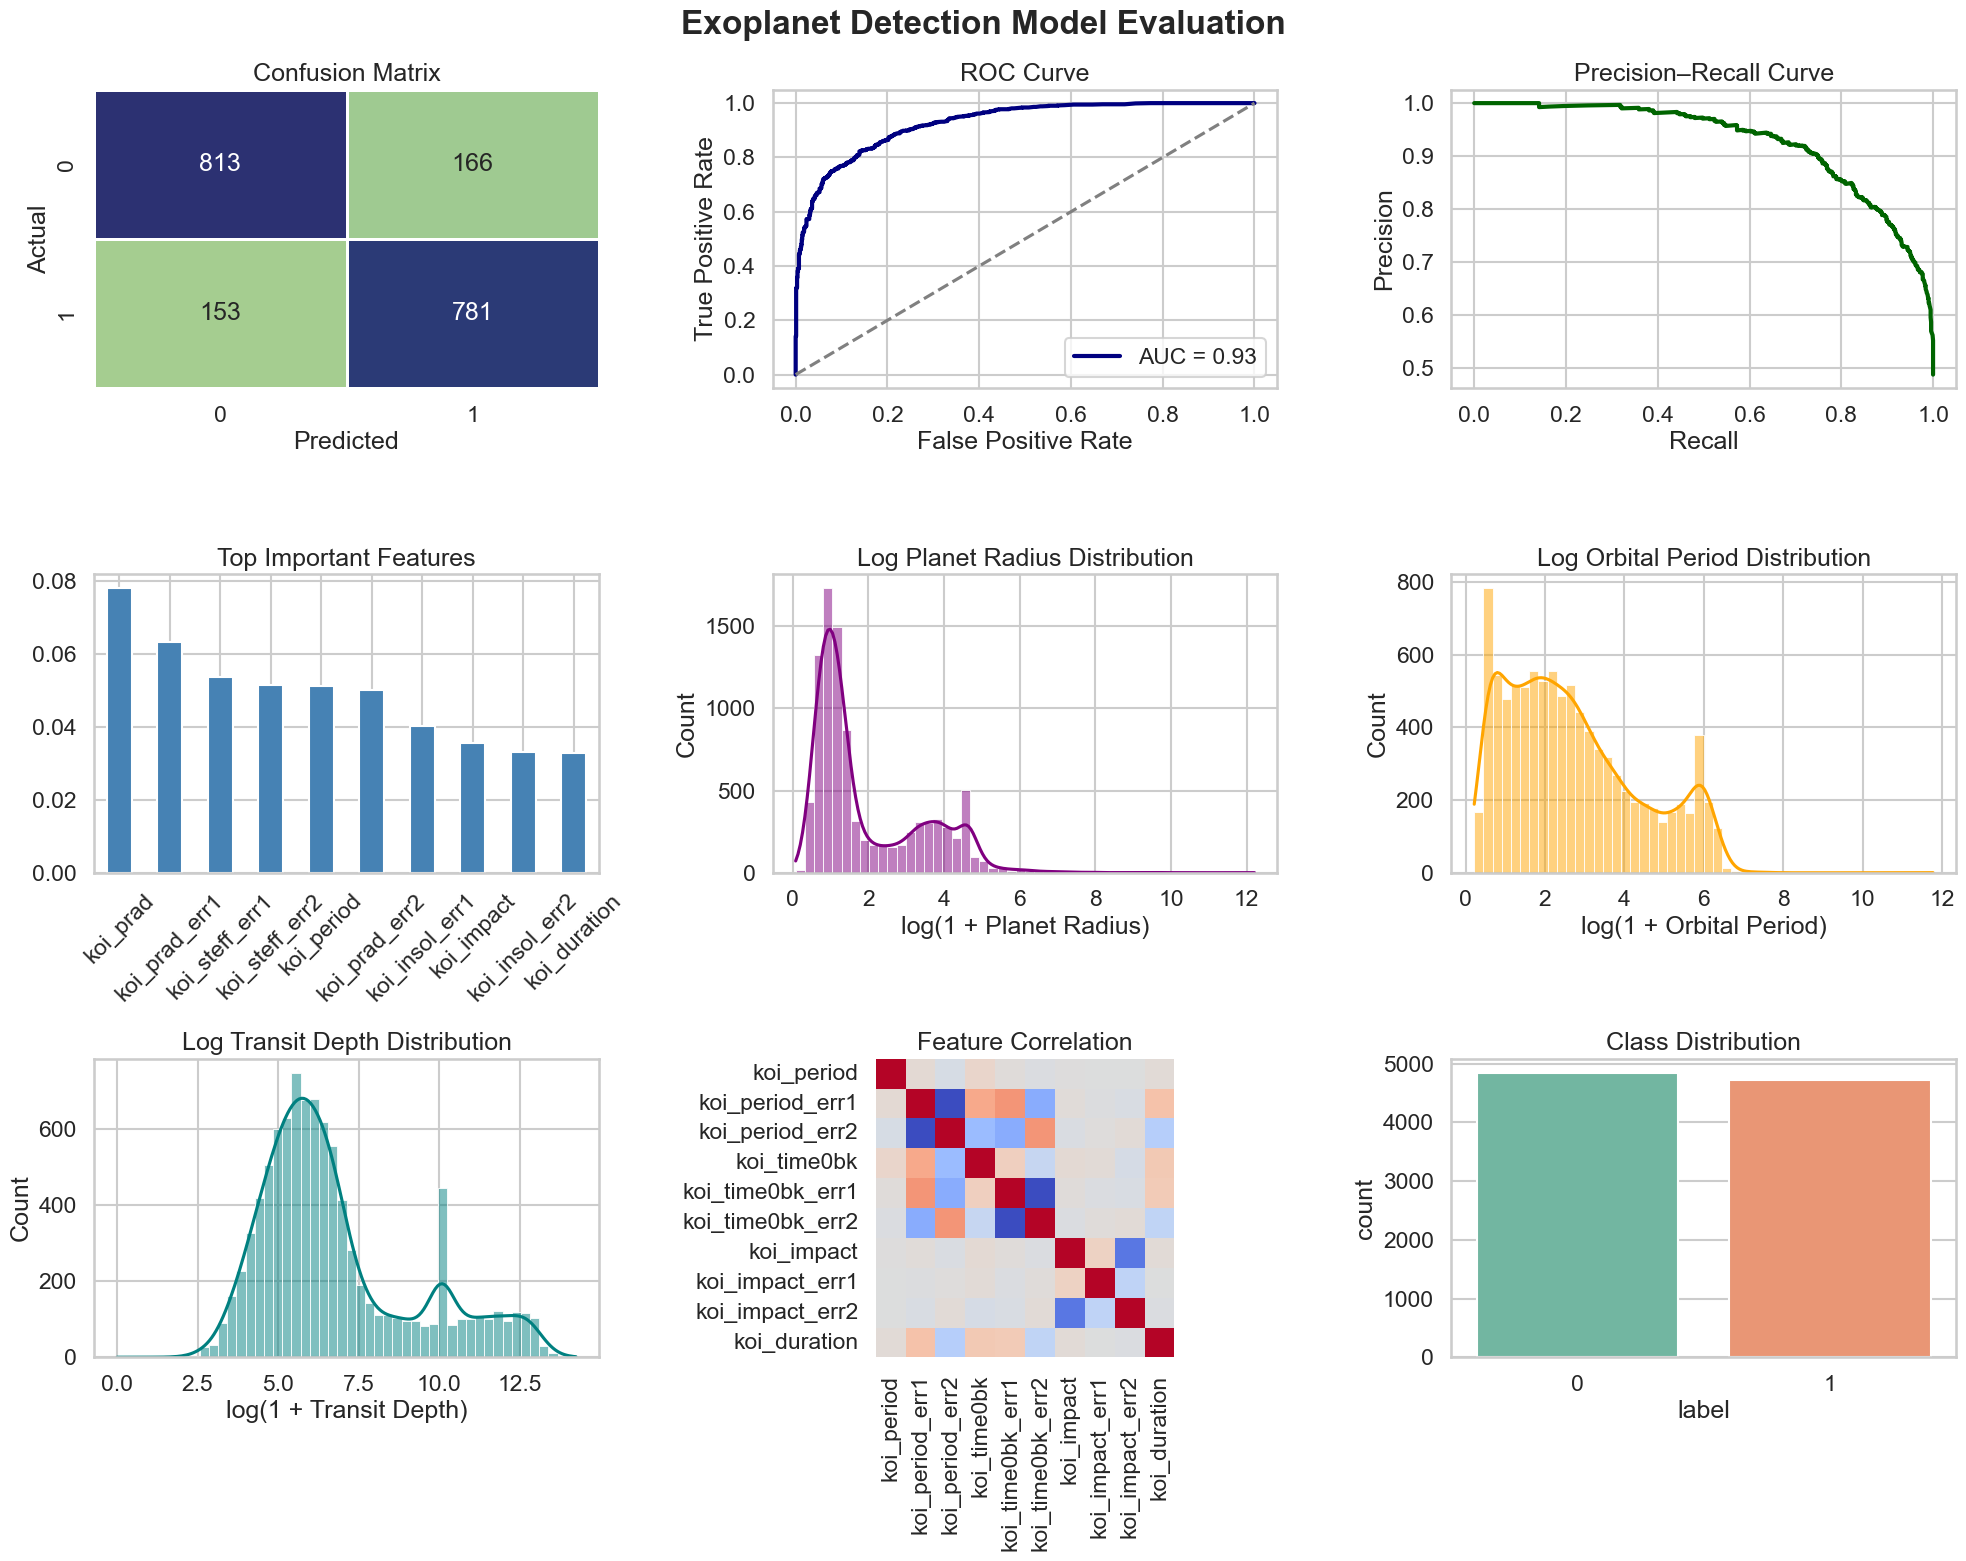

In [48]:

from sklearn.metrics import (
    confusion_matrix,
    roc_curve,
    auc,
    precision_recall_curve
)

# -----------------------------
# Plot style
# -----------------------------

sns.set_theme(style="whitegrid", context="talk")

fig, axes = plt.subplots(3, 3, figsize=(20,16))
fig.suptitle("Exoplanet Detection Model Evaluation", fontsize=24, fontweight="bold")

# ---------------------------------------------------
# Get prediction probabilities
# ---------------------------------------------------

y_prob = best_model.predict_proba(X_test)[:,1]

# ---------------------------------------------------
# 1. Confusion Matrix
# ---------------------------------------------------

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="crest",
    linewidths=1,
    cbar=False,
    ax=axes[0,0]
)

axes[0,0].set_title("Confusion Matrix")
axes[0,0].set_xlabel("Predicted")
axes[0,0].set_ylabel("Actual")

# ---------------------------------------------------
# 2. ROC Curve
# ---------------------------------------------------

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

axes[0,1].plot(fpr, tpr, lw=3, color="navy", label=f"AUC = {roc_auc:.2f}")
axes[0,1].plot([0,1],[0,1],'--', color="gray")

axes[0,1].set_title("ROC Curve")
axes[0,1].set_xlabel("False Positive Rate")
axes[0,1].set_ylabel("True Positive Rate")
axes[0,1].legend()

# ---------------------------------------------------
# 3. Precision-Recall Curve
# ---------------------------------------------------

precision, recall, _ = precision_recall_curve(y_test, y_prob)

axes[0,2].plot(recall, precision, lw=3, color="darkgreen")

axes[0,2].set_title("Precision–Recall Curve")
axes[0,2].set_xlabel("Recall")
axes[0,2].set_ylabel("Precision")

# ---------------------------------------------------
# 4. Feature Importance
# ---------------------------------------------------

importance = pd.Series(
    best_model.feature_importances_,
    index=X.columns
)

top_features = importance.sort_values(ascending=False).head(10)

top_features.plot.bar(
    ax=axes[1,0],
    color="steelblue"
)

axes[1,0].set_title("Top Important Features")
axes[1,0].tick_params(axis="x", rotation=45)

# ---------------------------------------------------
# 5. Log Planet Radius Distribution
# ---------------------------------------------------

sns.histplot(
    np.log1p(df["koi_prad"]),
    bins=50,
    kde=True,
    color="purple",
    ax=axes[1,1]
)

axes[1,1].set_title("Log Planet Radius Distribution")
axes[1,1].set_xlabel("log(1 + Planet Radius)")

# ---------------------------------------------------
# 6. Log Orbital Period Distribution
# ---------------------------------------------------

sns.histplot(
    np.log1p(df["koi_period"]),
    bins=50,
    kde=True,
    color="orange",
    ax=axes[1,2]
)

axes[1,2].set_title("Log Orbital Period Distribution")
axes[1,2].set_xlabel("log(1 + Orbital Period)")

# ---------------------------------------------------
# 7. Log Transit Depth Distribution
# ---------------------------------------------------

sns.histplot(
    np.log1p(df["koi_depth"]),
    bins=50,
    kde=True,
    color="teal",
    ax=axes[2,0]
)

axes[2,0].set_title("Log Transit Depth Distribution")
axes[2,0].set_xlabel("log(1 + Transit Depth)")

# ---------------------------------------------------
# 8. Feature Correlation
# ---------------------------------------------------

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr.iloc[:10,:10],
    cmap="coolwarm",
    square=True,
    cbar=False,
    ax=axes[2,1]
)

axes[2,1].set_title("Feature Correlation")

# ---------------------------------------------------
# 9. Class Distribution
# ---------------------------------------------------

sns.countplot(
    x="label",
    data=df,
    palette="Set2",
    ax=axes[2,2]
)

axes[2,2].set_title("Class Distribution")

# ---------------------------------------------------
# Layout
# ---------------------------------------------------

plt.tight_layout()
plt.show()

In [49]:
from sklearn.metrics import accuracy_score, roc_auc_score
import pandas as pd

# Random Forest performance
rf_accuracy = accuracy_score(y_test, y_pred)
rf_auc = roc_auc_score(y_test, y_prob)

# XGBoost performance
xgb_accuracy = accuracy_score(y_test, y_pred_xgb)
xgb_auc = roc_auc_score(y_test, y_prob_xgb)

comparison = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost"],
    "Accuracy": [rf_accuracy, xgb_accuracy],
    "ROC_AUC": [rf_auc, xgb_auc]
})

print("Model Performance Comparison")
print(comparison)

Model Performance Comparison
           Model  Accuracy   ROC_AUC
0  Random Forest  0.833246  0.926411
1        XGBoost  0.852065  0.934445


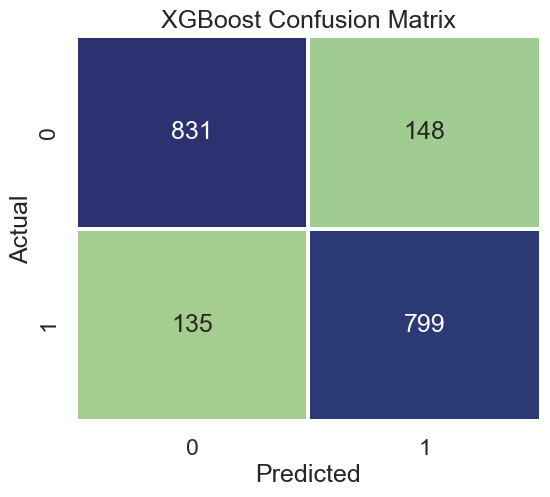

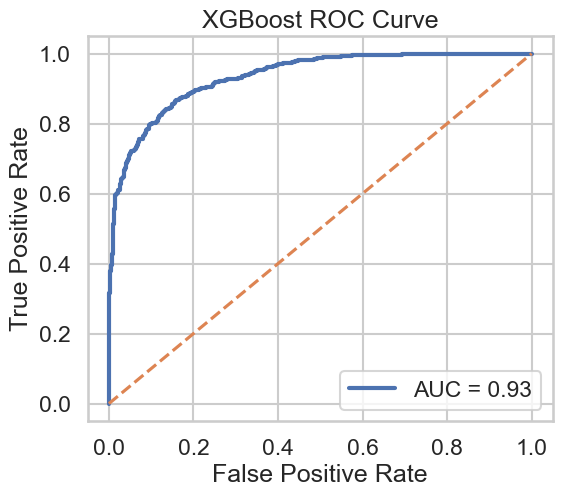

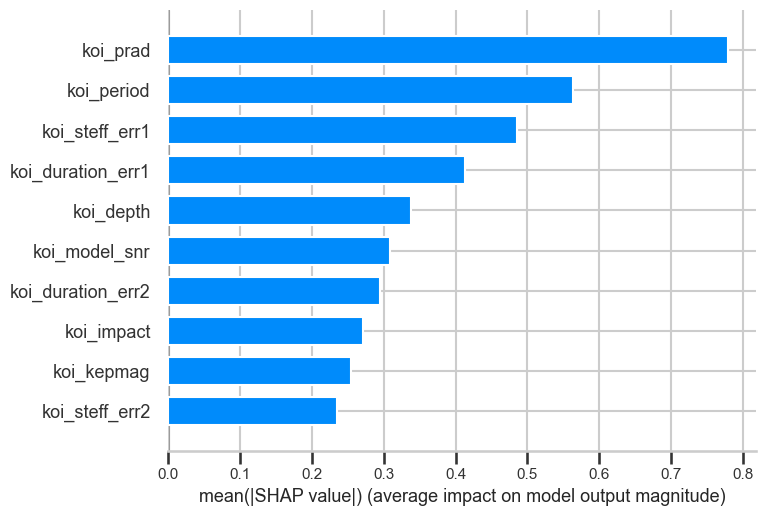

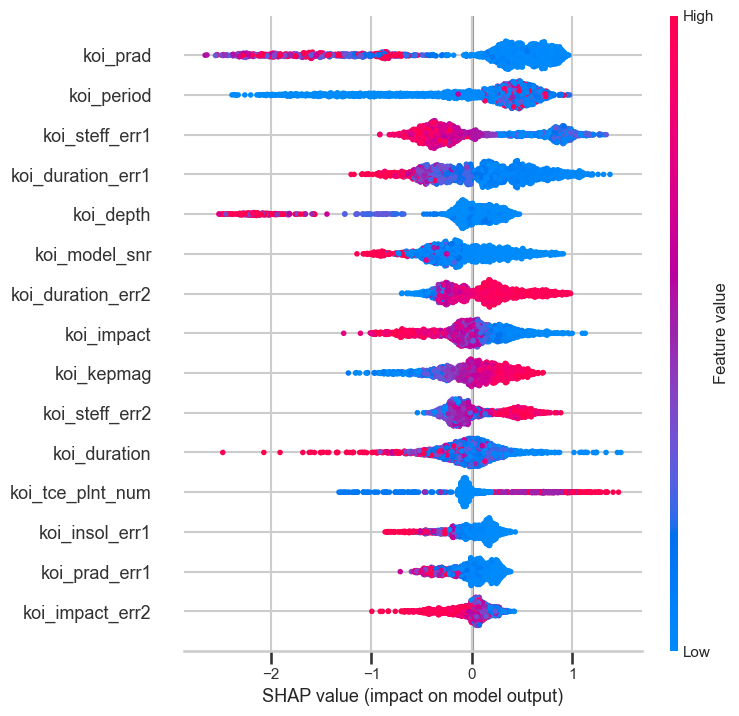

In [50]:
import shap
from sklearn.metrics import confusion_matrix, roc_curve, auc

# -----------------------------
# Confusion Matrix
# -----------------------------

cm = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="crest",
    linewidths=1.5,
    cbar=False
)

plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()


# -----------------------------
# ROC Curve
# -----------------------------

fpr, tpr, _ = roc_curve(y_test, y_prob_xgb)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, lw=3, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'--')

plt.title("XGBoost ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.show()


# -----------------------------
# SHAP Explainability
# -----------------------------

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)


# -----------------------------
# SHAP Feature Importance
# -----------------------------

plt.figure(figsize=(8,6))

shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar",
    max_display=10
)


# -----------------------------
# SHAP Summary Plot
# -----------------------------

plt.figure(figsize=(8,6))

shap.summary_plot(
    shap_values,
    X_test,
    max_display=15
)

In [52]:
import joblib

joblib.dump(xgb_model, "exoplanet_model.pkl")

print("Model saved successfully")

Model saved successfully


In [ ]:


# load saved model
model = joblib.load("exoplanet_model.pkl")

# take structure from dataset so columns match
sample = X_test.iloc[[0]].copy()

print("Enter values for a new planet candidate")

sample["koi_prad"] = float(input("Planet radius (Earth radii): "))
sample["koi_period"] = float(input("Orbital period (days): "))
sample["koi_depth"] = float(input("Transit depth: "))
sample["koi_duration"] = float(input("Transit duration (hours): "))

prediction = model.predict(sample)
prob = model.predict_proba(sample)

if prediction[0] == 1:
    print("\n🌍 Planet candidate detected")
else:
    print("\n❌ Likely false signal")

print("Planet probability:", prob[0][1])

Enter values for a new planet candidate
